In [109]:
# introduces a big range of pairs - SAM and BF-B were chose bc it gave best / most accurate results
# out of all stocks i listed, so cannot be fully certain that this method works in general or it 
# was just because of their strong correlation.

# additions:
# portfolio of pairs
# cointegration breakdown stoploss - if a pair of stocks begin drifting / dont run together, exit the position
# walk-forward validation - fit on rolling basis instead of over whole sample tested on same data - checks whether it would work real time

# going to use static hedge ratio instead of dynamic - may look at changing in future

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

from utils import compute_zscore, generate_signals, backtest, sharpe_ratio
from utils import cointegration_test, estimate_hedge_ratio

import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams["figure.figsize"] = (12, 5)




In [110]:
# pick portfolio of pairs

PORTFOLIO_PAIRS = {
    ("SAM", "BF-B"),
    ("COP", "EOG"),
    ("BAC", "PNC"),
    ("INTC", "MU"),
}

all_tickers = sorted(set(t for pair in PORTFOLIO_PAIRS for t in pair))

START_DATE = "2022-01-01"
END_DATE = "2024-01-01"

prices = yf.download(all_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]
prices = prices.dropna()
prices.head()

[*********************100%***********************]  8 of 8 completed


Ticker,BAC,BF-B,COP,EOG,INTC,MU,PNC,SAM
Date,,,,,,,,
2022-01-03,41.055866,64.820709,62.326160,73.999130,49.350483,93.599594,174.387604,520.200012
2022-01-04,42.665047,64.675842,65.029762,77.400345,49.285564,94.176331,180.811386,508.170013
2022-01-05,41.944912,65.056129,63.914520,75.979774,49.962608,92.279915,177.880066,502.220001
2022-01-06,42.789501,62.683884,66.313957,77.538338,50.092457,93.501839,184.730942,499.329987
2022-01-07,43.722992,61.706005,68.130409,79.681374,49.563805,92.328796,187.377502,516.880005


In [111]:
# walk forward windows
# pick a training length eg 12months, and testing eg 3months, fit tests on the training window, so that it uses the past tests
# to trade on the test window, which it hasnt seen before. then shift forward by the test window, so all trades are executed
# on new, unseen data

def generate_walk_forward_windows(start_date: str, end_date: str, train_months: int = 12, test_months: int = 3) -> list:

    train_start = pd.Timestamp(start_date)
    max_end = pd.Timestamp(end_date)
    windows = []

    while True:
        
        train_end = train_start + pd.DateOffset(months=train_months)
        test_start = train_end
        test_end = test_start + pd.DateOffset(months=test_months)

        if test_end > max_end:
            break

        windows.append((train_start, train_end, test_start, test_end))

        train_start += pd.DateOffset(months=test_months)

    return windows

windows = generate_walk_forward_windows(START_DATE, END_DATE, train_months=12, test_months=3)
print(f"{len(windows)} walk-forward windows generated")
for w in windows:
    print(w)



4 walk-forward windows generated
(Timestamp('2022-01-01 00:00:00'), Timestamp('2023-01-01 00:00:00'), Timestamp('2023-01-01 00:00:00'), Timestamp('2023-04-01 00:00:00'))
(Timestamp('2022-04-01 00:00:00'), Timestamp('2023-04-01 00:00:00'), Timestamp('2023-04-01 00:00:00'), Timestamp('2023-07-01 00:00:00'))
(Timestamp('2022-07-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2023-10-01 00:00:00'))
(Timestamp('2022-10-01 00:00:00'), Timestamp('2023-10-01 00:00:00'), Timestamp('2023-10-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))


In [112]:
def run_walk_forward_pair(prices: pd.DataFrame, ticker_a: str, ticker_b: str, windows: list, 
                          pvalue_threshold: float = 0.05, entry_threshold: float = 1.0,
                          exit_threshold: float = 0.5) -> tuple:

    all_pnl = []
    log_records = []

    for train_start, train_end, test_start, test_end in windows:

        train_a = prices.loc[train_start:train_end, ticker_a]
        train_b = prices.loc[train_start:train_end, ticker_b]

        test_a = prices.loc[test_start:test_end, ticker_a]
        test_b = prices.loc[test_start:test_end, ticker_b]

        # Cointegration test on training period
        test_statistics, p_value = cointegration_test(train_a, train_b)

        if p_value > pvalue_threshold:
            log_records.append({
                'train_start': train_start, 'train_end': train_end,
                'test_start': test_start, 'test_end': test_end,
                'p_value': p_value, 'traded': False
            })
            continue

        alpha, beta, train_spread = estimate_hedge_ratio(train_a, train_b)

        train_mean = train_spread.mean()
        train_std = train_spread.std()

        # Construct test spread and z-score using train stats
        test_spread = test_a - (alpha + beta * test_b)
        test_zscore = (test_spread - train_mean) / train_std

        # FIXED: Pass exit_threshold properly
        positions = generate_signals(test_zscore, entry_threshold=entry_threshold, exit_threshold=exit_threshold)
        daily_pnl = backtest(positions, test_spread)

        all_pnl.append(daily_pnl)
        log_records.append({
            'train_start': train_start, 'train_end': train_end,
            'test_start': test_start, 'test_end': test_end,
            'p_value': p_value, 'traded': True
        })

    if all_pnl:
        combined_pnl = pd.concat(all_pnl)
        # Remove boundary overlap dates if multiple windows trade
        combined_pnl = combined_pnl[~combined_pnl.index.duplicated(keep='first')]
    else:
        combined_pnl = pd.Series(dtype=float)

    window_log = pd.DataFrame(log_records)

    return combined_pnl, window_log


sam_bfb_pnl, sam_bfb_log = run_walk_forward_pair(prices, "SAM", "BF-B", windows)
print(sam_bfb_pnl, sam_bfb_log)

print(f"Windows traded: {sam_bfb_log['traded'].sum()} / {len(sam_bfb_log)}")
sr = sharpe_ratio(sam_bfb_pnl.dropna())
print(f"Walk-forward out-of-sample Sharpe (SAM/BF-B): {sr:.2f}")


Date
2023-01-03         NaN
2023-01-04    5.526227
2023-01-05   -4.646040
2023-01-06    4.721279
2023-01-09   -5.853833
                ...   
2023-03-27    2.209124
2023-03-28   -3.504824
2023-03-29    2.695328
2023-03-30    0.768427
2023-03-31    2.211561
Length: 62, dtype: float64   train_start  train_end test_start   test_end   p_value  traded
0  2022-01-01 2023-01-01 2023-01-01 2023-04-01  0.020945    True
1  2022-04-01 2023-04-01 2023-04-01 2023-07-01  0.052710   False
2  2022-07-01 2023-07-01 2023-07-01 2023-10-01  0.082072   False
3  2022-10-01 2023-10-01 2023-10-01 2024-01-01  0.323046   False
Windows traded: 1 / 4
Walk-forward out-of-sample Sharpe (SAM/BF-B): 3.69


In [113]:
def run_portfolio_walk_forward(prices: pd.DataFrame, pairs: list, windows: list) -> dict:
    portfolio_pnls = {}

    for ticker_a, ticker_b in PORTFOLIO_PAIRS:
        pair_name = f"{ticker_a}/{ticker_b}"
        combined_pnl, window_log = run_walk_forward_pair(prices, ticker_a, ticker_b, windows)
        portfolio_pnls[pair_name] = combined_pnl

    return portfolio_pnls

pair_pnls = run_portfolio_walk_forward(prices, PORTFOLIO_PAIRS, windows)

        

<Axes: title={'center': 'Portfolio cumulative P&L (walk-forward, out-of-sample)'}>

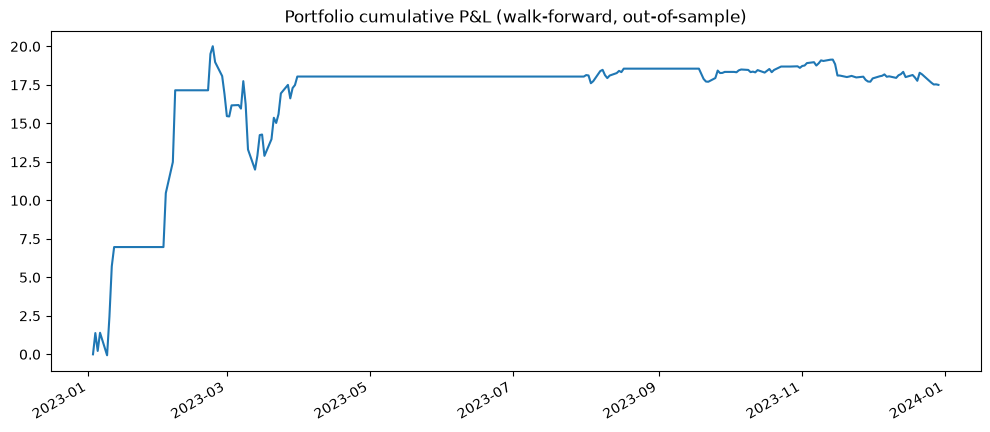

In [114]:
def combine_portfolio(pair_pnls: dict) -> pd.Series:

    # get into single dataframe
    pnl_df = pd.concat(pair_pnls, axis=1)

    pnl_df = pnl_df.fillna(0)

    portfolio_pnl = pnl_df.mean(axis=1)

    portfolio_pnl.index = pd.to_datetime(portfolio_pnl.index)
    portfolio_pnl = portfolio_pnl.sort_index()
    portfolio_pnl = portfolio_pnl[~portfolio_pnl.index.duplicated(keep='first')]

    return portfolio_pnl

portfolio_pnl = combine_portfolio(pair_pnls)
portfolio_cumulative = portfolio_pnl.cumsum()
portfolio_cumulative.plot(title="Portfolio cumulative P&L (walk-forward, out-of-sample)")



In [115]:
def max_drawdown(cumulative_pnl: pd.Series) -> float:

    running_max = portfolio_cumulative.cummax()

    drawdown = portfolio_cumulative - running_max

    return drawdown.min()

mdd = max_drawdown(portfolio_cumulative)
print(f"Portfolio max drawdown: {mdd:.2f}")

Portfolio max drawdown: -8.02


In [118]:
# stats
print(f"Portfolio walk-forward Sharpe: {sharpe_ratio(portfolio_pnl.dropna()):.2f}")
print(f"Portfolio max drawdown: {mdd:.2f}")
for pair_name, pnl in pair_pnls.items():
    if pnl.dropna().empty:
        print(f"{pair_name}: never traded (failed cointegration in every walk-forward window)")
    else:
        print(f"{pair_name}: walk-forward Sharpe = {sharpe_ratio(pnl.dropna()):.2f}")

Portfolio walk-forward Sharpe: 1.98
Portfolio max drawdown: -8.02
COP/EOG: walk-forward Sharpe = 0.48
BAC/PNC: never traded (failed cointegration in every walk-forward window)
SAM/BF-B: walk-forward Sharpe = 3.69
INTC/MU: walk-forward Sharpe = -1.17


In [ ]:
_, bac_pnc_log = run_walk_forward_pair(prices, "BAC", "PNC", windows)
bac_pnc_log


,train_start,train_end,test_start,test_end,p_value,traded
0,2022-01-01,2023-01-01,2023-01-01,2023-04-01,0.154451,False
1,2022-04-01,2023-04-01,2023-04-01,2023-07-01,0.174568,False
2,2022-07-01,2023-07-01,2023-07-01,2023-10-01,0.142630,False
3,2022-10-01,2023-10-01,2023-10-01,2024-01-01,0.060190,False
